In [82]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [58]:
df=pd.read_csv("D:/Project_Folder_All/Customer_Churn_Prediction(XG)/data/raw/churnData.csv")

In [59]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [60]:
df.shape

(7043, 21)

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [62]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [64]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [65]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [66]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [67]:
df[df['TotalCharges'].astype('str').str.strip() ==""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [68]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [69]:
for col in df.columns:
    print(col ,"->" ,df[col].nunique())

customerID -> 7043
gender -> 2
SeniorCitizen -> 2
Partner -> 2
Dependents -> 2
tenure -> 73
PhoneService -> 2
MultipleLines -> 3
InternetService -> 3
OnlineSecurity -> 3
OnlineBackup -> 3
DeviceProtection -> 3
TechSupport -> 3
StreamingTV -> 3
StreamingMovies -> 3
Contract -> 3
PaperlessBilling -> 2
PaymentMethod -> 4
MonthlyCharges -> 1585
TotalCharges -> 6531
Churn -> 2


In [70]:
for col in df.select_dtypes(include='str').columns:
    if col not in ['customerID',"Churn"]:
        print(f"\n======={col}====")
        print(df.groupby(col)['Churn'].value_counts(normalize=True).unstack())


=======gender====
Churn         No       Yes
gender                    
Female  0.730791  0.269209
Male    0.738397  0.261603

=======Partner====
Churn          No       Yes
Partner                    
No       0.670420  0.329580
Yes      0.803351  0.196649

=======Dependents====
Churn             No       Yes
Dependents                    
No          0.687209  0.312791
Yes         0.845498  0.154502

=======PhoneService====
Churn               No       Yes
PhoneService                    
No            0.750733  0.249267
Yes           0.732904  0.267096

=======MultipleLines====
Churn                   No       Yes
MultipleLines                       
No                0.749558  0.250442
No phone service  0.750733  0.249267
Yes               0.713901  0.286099

=======InternetService====
Churn                  No       Yes
InternetService                    
DSL              0.810409  0.189591
Fiber optic      0.581072  0.418928
No               0.925950  0.074050

=======OnlineSecu

In [71]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors="coerce")

In [72]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [73]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [74]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [75]:
df['TotalCharges']=df['TotalCharges'].fillna(0)

In [76]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [79]:
df.duplicated().sum()

np.int64(0)

In [80]:
df=df.drop(columns=['customerID'])

[]

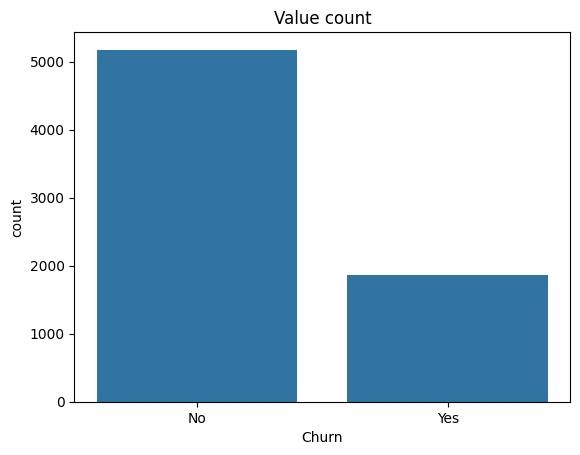

In [ ]:
sns.countplot(data=df,x="Churn")
plt.title("Value count")
plt.plot()

In [87]:
df[['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


[]

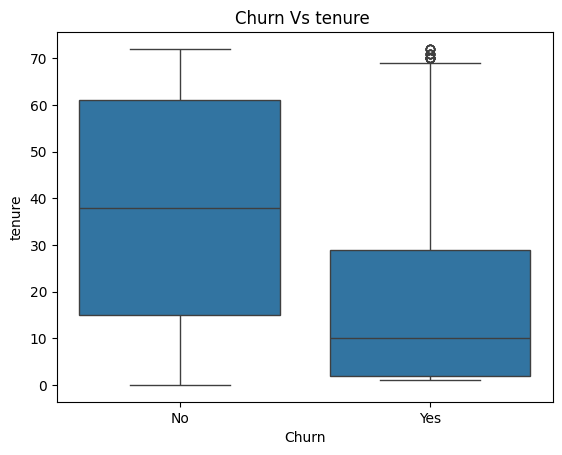

In [91]:
sns.boxplot(data=df,x='Churn',y='tenure')
plt.title("Churn Vs tenure ")
plt.plot()

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

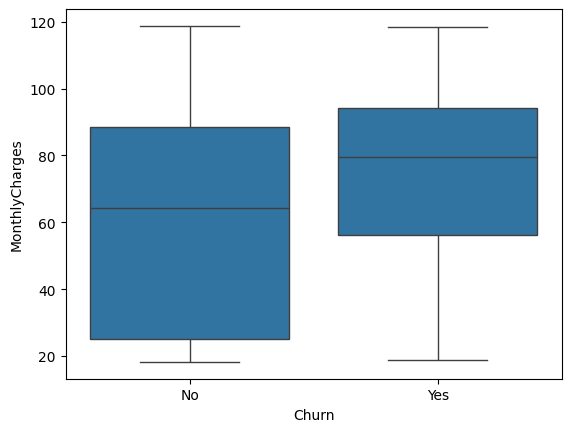

In [89]:
sns.boxplot(data=df,x='Churn',y='MonthlyCharges')

In [90]:
print(
    df.groupby("Churn")[
        ["tenure", "MonthlyCharges", "TotalCharges"]
    ].mean()
)

          tenure  MonthlyCharges  TotalCharges
Churn                                         
No     37.569965       61.265124   2549.911442
Yes    17.979133       74.441332   1531.796094


In [ ]:
pd.crosstab(df['Contract'],df['Churn'],normalize=True)

Churn,No,Yes
Contract,,
Month-to-month,0.315207,0.234985
One year,0.185574,0.023570
Two year,0.233849,0.006815


In [96]:
for col in df.select_dtypes(include='str').columns:
    if col not in ["Churn"]:
        print("==============================================")
        print(pd.crosstab(df[col],df["Churn"],normalize=True))


Churn        No       Yes
gender                   
Female  0.36192  0.133324
Male    0.37271  0.132046
Churn          No       Yes
Partner                    
No       0.346585  0.170382
Yes      0.388045  0.094988
Churn             No       Yes
Dependents                    
No          0.481329  0.219083
Yes         0.253301  0.046287
Churn               No       Yes
PhoneService                    
No            0.072696  0.024137
Yes           0.661934  0.241232
Churn                   No       Yes
MultipleLines                       
No                0.360784  0.120545
No phone service  0.072696  0.024137
Yes               0.301150  0.120687
Churn                  No       Yes
InternetService                    
DSL              0.278574  0.065171
Fiber optic      0.255431  0.184154
No               0.200625  0.016044
Churn                      No       Yes
OnlineSecurity                         
No                   0.289223  0.207440
No internet service  0.200625  0.016044
Yes

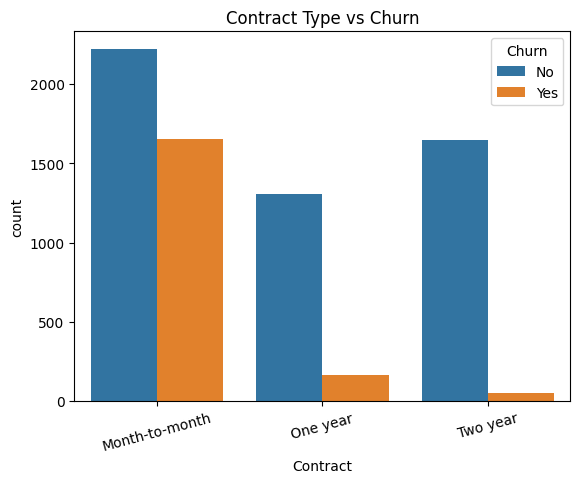

In [97]:
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

In [99]:
df['Churn']=df['Churn'].map({'Yes':1,'No':0})

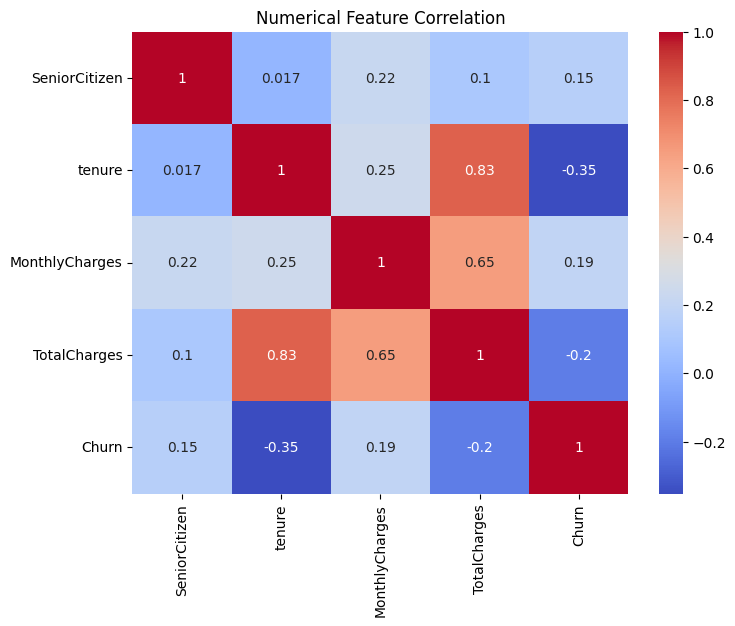

In [100]:
numeric_df = df[
    ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Numerical Feature Correlation")
plt.show()

# Exploratory Data Analysis (EDA) Summary

## 1. Data Overview & Data Quality

- **Dataset dimensions:** 7,043 rows and 21 columns.
- The dataset contains numerical and categorical variables:
  - `float64`: 1 column initially
  - `int64`: 2 columns
  - `object/str`: 18 columns
- `TotalCharges` contained numerical values stored as strings. After converting it to a numeric type, **11 missing values** were identified.
- All 11 missing `TotalCharges` values corresponded to customers with `tenure = 0`. These customers appear to be new sign-ups without accumulated billing history, so the missing values were replaced with **0**.
- No duplicate customer records were identified.
- `customerID` was removed because it is an identifier and does not provide meaningful predictive information for churn.
- The target variable `Churn` was encoded as:
  - `No → 0`
  - `Yes → 1`

---

## 2. Numerical Feature Analysis

### `tenure`

`tenure` showed the strongest negative correlation with the encoded churn target among the numerical features examined (**r ≈ -0.35**).

Customers with longer tenure generally show lower churn rates, while customers with shorter tenure tend to have higher churn rates.

### `MonthlyCharges`

`MonthlyCharges` showed a positive association with churn (**r ≈ +0.19**).

Customers with higher monthly charges tend to exhibit higher churn rates.

### `TotalCharges`

`TotalCharges` showed a negative association with churn (**r ≈ -0.20**).

Customers with higher total spending tend to churn less. This relationship is partly explained by the strong relationship between total spending and tenure: customers who remain with the service longer naturally accumulate higher total charges.

### `SeniorCitizen`

`SeniorCitizen` showed a weaker positive association with churn (**r ≈ +0.15**), indicating that senior customers exhibit somewhat higher churn rates than non-senior customers.

> **Note:** Correlation indicates association and does not establish causal relationships or actual model feature importance. Model-based feature importance will be evaluated during the modeling stage.

---

## 3. Categorical Feature Analysis

### Stronger Churn Associations

#### Contract

Contract type shows a strong association with churn.

- Month-to-month customers exhibit substantially higher churn.
- One-year contract customers have considerably lower churn.
- Two-year contract customers have the lowest churn.

This suggests that contract commitment is an important candidate feature for predicting churn.

#### Internet Service

Fiber-optic customers show noticeably higher churn than DSL customers and customers without internet service.

#### Payment Method

Customers using **Electronic Check** show substantially higher churn than customers using automatic bank transfer, automatic credit card, or mailed check payment methods.

#### Paperless Billing

Customers using paperless billing show higher churn rates than customers using non-paperless billing.

#### Security and Technical Support Services

Customers without services such as:

- `OnlineSecurity`
- `TechSupport`
- `DeviceProtection`
- `OnlineBackup`

show higher churn rates than customers subscribed to these services.

#### Partner and Dependents

Customers without a partner or dependents generally show higher churn rates than customers with partners or dependents.

---

## 4. Weaker Churn Associations

### Gender

Male and female customers show very similar churn rates, suggesting little marginal association between gender and churn.

### Phone and Streaming Services

`PhoneService`, `MultipleLines`, `StreamingTV`, and `StreamingMovies` show weaker marginal associations with churn compared with features such as contract type, tenure, and payment method.

However, these features will not be removed solely based on univariate EDA because tree-based models can capture interactions between multiple features.

---

## 5. Key EDA Findings

The EDA indicates that churn is associated with several aspects of customer behavior and service configuration:

- **Shorter tenure** is associated with higher churn.
- **Higher monthly charges** are associated with higher churn.
- **Month-to-month contracts** are strongly associated with churn.
- **Fiber-optic internet service** is associated with higher churn.
- **Electronic-check payment** is associated with higher churn.
- **Paperless billing** is associated with higher churn.
- Customers without **security and technical-support services** tend to churn more frequently.
- **Gender** shows little apparent association with churn.
- `TotalCharges` is negatively associated with churn, partly because it is strongly related to customer tenure.

---

## 6. Modeling Implications

Based on the EDA:

- `customerID` will be excluded because it is an identifier rather than a meaningful predictive feature.
- The remaining potentially predictive features will initially be retained.
- Features will not be removed solely because they appear weak in univariate analysis.
- Model-based feature importance and feature interactions will be evaluated during the modeling stage.
- Because churn is a binary classification target and the classes are imbalanced, **accuracy alone will not be sufficient for evaluating the models**.
- Precision, recall, F1-score, ROC-AUC, and the confusion matrix will be considered during model evaluation.

---

## 7. Conclusion

The EDA indicates that customer churn is influenced by a combination of **customer tenure, pricing, contract structure, service configuration, payment behavior, and customer characteristics**. Several variables show meaningful marginal associations with churn, while others appear weaker when examined individually.

The next stage is to construct a **leakage-safe preprocessing pipeline** that converts the remaining categorical features into a numerical representation while ensuring that preprocessing is learned only from the training data.